In [1]:
import torch
from torch import nn

In [77]:
def my_scaled_dot_product_attention(query, key=None, value=None):
    key = key if key is not None else query
    value = value if value is not None else query
    # query and key must have same embedding dimension
    assert query.size(-1) == key.size(-1)

    dk = key.size(-1) # embed dimension of key
    # query, key, value = (bs, seq_len, embed_dim)

    # compute dot-product to obtain pairwise "similarity" and scale it
    qk = query @ key.transpose(-1, -2) / dk**0.5

    # apply softmax
    # attn_weights = (bs, seq_len, seq_len)
    attn_weights = torch.softmax(qk, dim=-1) ## horizontally softmax

    # compute weighted sum of value vectors
    # attn = (bs, seq_len, embed_dim)
    attn = attn_weights @ value
    return attn, attn_weights

In [3]:
# x=torch.rand(4,5)
my_scaled_dot_product_attention(torch.rand(4,5))

(tensor([[0.5791, 0.4059, 0.5795, 0.3757, 0.7928],
         [0.5543, 0.3878, 0.6216, 0.3068, 0.8139],
         [0.5529, 0.3711, 0.6403, 0.2856, 0.8145],
         [0.5475, 0.4049, 0.6244, 0.2959, 0.8223]]),
 tensor([[0.3222, 0.2217, 0.2114, 0.2447],
         [0.2387, 0.2421, 0.2499, 0.2693],
         [0.2165, 0.2378, 0.2836, 0.2621],
         [0.2273, 0.2324, 0.2377, 0.3026]]))

In [4]:
X = torch.normal(mean=0, std=1, size=(2, 3, 5))


In [5]:
torch.nn.functional.scaled_dot_product_attention(X, X, X)

tensor([[[-0.3782, -1.4187,  0.3404,  1.1711, -0.5812],
         [-0.3153,  0.6057, -1.9741,  0.5738,  1.3703],
         [ 0.0576, -1.3648,  1.2697,  0.7376, -0.5970]],

        [[ 0.7450, -1.1302, -0.2357,  2.7376,  0.2768],
         [ 3.3517,  0.4008, -0.5043,  0.4365,  0.7221],
         [ 0.0969,  0.9285, -0.1393,  0.5352, -0.1119]]])

In [6]:
my_scaled_dot_product_attention(X, X, X)

(tensor([[[-0.3782, -1.4187,  0.3404,  1.1711, -0.5812],
          [-0.3153,  0.6057, -1.9741,  0.5738,  1.3703],
          [ 0.0576, -1.3648,  1.2697,  0.7376, -0.5970]],
 
         [[ 0.7450, -1.1302, -0.2357,  2.7376,  0.2768],
          [ 3.3517,  0.4008, -0.5043,  0.4365,  0.7221],
          [ 0.0969,  0.9285, -0.1393,  0.5352, -0.1119]]]),
 tensor([[[0.7144, 0.0400, 0.2456],
          [0.0256, 0.9702, 0.0042],
          [0.2525, 0.0068, 0.7407]],
 
         [[0.9537, 0.0414, 0.0050],
          [0.0137, 0.9846, 0.0017],
          [0.1250, 0.1312, 0.7438]]]))

In [7]:
X = torch.normal(mean=0, std=1, size=(2, 3, 6))
torch_attended = torch.nn.functional.scaled_dot_product_attention(X, X, X)
attended, attn_weights = my_scaled_dot_product_attention(X, X, X)
torch.allclose(torch_attended, attended)

True

In [9]:
batch_size=3

A=torch.rand(batch_size,10,256)  ## We have 3 sequences each with 10 tokens and each token had a dimension of 256

output=[]
for batch_idx in range(batch_size):
    pairwise_dot_product=A[batch_idx]@A[batch_idx].transpose(-1,-2) ## A*A.t
    output.append(pairwise_dot_product)


In [10]:
type(output[0])

torch.Tensor

In [11]:
batch_size=3
num_heads=4
seq_len=10
embed_dim=6

A=torch.rand(batch_size,num_heads,seq_len,embed_dim)  ## We have 3 sequences each with 10 tokens and each token had a dimension of 256, number of heads is 2

A[0] ## first batch with 4 heads

output=[]

for batch_idx in range(0,batch_size):
  output_per_head=[]
  for head_idx in range(0,num_heads):
    pairwise_dot_product=A[batch_idx][head_idx]@A[batch_idx][head_idx].transpose(-1,-2)
    output_per_head.append(pairwise_dot_product)
  output.append(output_per_head)



In [12]:
output[0][0].shape

torch.Size([10, 10])

In [76]:
class AttentionBlock(nn.Module):
    def __init__(self,input_dim:int,output_dim:int,bias=False):
        super().__init__()
        ## in_features = embed_dim, out_features=head_dim
        self.W_q=torch.nn.Linear(input_dim,output_dim,bias=bias)
        self.W_k=torch.nn.Linear(input_dim,output_dim,bias=bias)
        self.W_v=torch.nn.Linear(input_dim,output_dim,bias=bias)

    def forward(self,query,key,value):
        ## project Q,K,V
        q_logits=self.W_q(query)
        k_logits=self.W_k(key)
        v_logits=self.W_v(value)

        # apply scaled dot product attention on projected values
        attn, weights = my_scaled_dot_product_attention(q_logits, k_logits, v_logits)
        return attn, weights



In [40]:
attention_block=AttentionBlock(6,6)
# attention_block(torch.rand([5,8]),torch.rand([5,8]),torch.rand([5,8]))[0] ## contextual embeddings

In [15]:
torch.nn.ModuleList([AttentionBlock(input_dim=10, output_dim=2, bias=False) for i in range(10)])[0]

AttentionBlock(
  (W_q): Linear(in_features=10, out_features=2, bias=False)
  (W_k): Linear(in_features=10, out_features=2, bias=False)
  (W_v): Linear(in_features=10, out_features=2, bias=False)
)

In [74]:
class MyMultiHeadAttention(nn.Module):
    def __init__(self,embed_dim:int,num_heads:int,projection_bias=False):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim=embed_dim
        self.num_heads=num_heads
        head_embed_dim=self.embed_dim // num_heads ##

        # for each head, create an attention block

        self.head_blocks=torch.nn.ModuleList([AttentionBlock(input_dim=embed_dim, output_dim=head_embed_dim, bias=projection_bias) for i in range(self.num_heads)])

        # final projection of MHA

        self.projection=torch.nn.Linear(embed_dim,embed_dim,bias=projection_bias)



    def forward(self,query,key,value):

        ## these lists are to store output of each head

        attns_list=[]
        attn_weights_list=[]

        # for every head pass the original query, key, value

        for head in self.head_blocks:
            attn, attn_weights=head(query, key, value)
            attns_list.append(attn)
            attn_weights_list.append(attn_weights)


        # concatenate attention outputs and take average of attention weights
        attns, attn_weights = torch.cat(attns_list, dim=1), torch.stack(attn_weights_list).mean(dim=0)
        # shape: (bs, seq_len, embed_dim), attn_weights: (bs, seq_len, seq_len)
        return self.projection(attns), attn_weights






In [111]:
multi_head_attention=MyMultiHeadAttention(10,2) ## (embed_dim,number of heads)
multi_head_attention(torch.rand([3,10]),torch.rand([3,10]),torch.rand([3,10])) ## passing the ordinary embeddings torch.rand([number of tokens,embed_dim])

RuntimeError: mat1 and mat2 shapes cannot be multiplied (24x5 and 10x10)

In [18]:
import datasets
from transformers import AutoTokenizer

C:\Users\Amrita\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [19]:
original_tokenizer=AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

news_ds=datasets.load_dataset("SetFit/bbc-news", split="train")
# train a new tokenizer with limited vocab size for demo

# To keep things small, I created a new tokenizer with same config as original_tokenizer but with vocabulary size of just 1000. 
# Original tokenizer has vocab size of 30,522 which results in large amount of data in Embedding layer. For this purpose 
# vocab size of 1000 is just fine and we can train our models quickly in CPU as well.

tokenizer = original_tokenizer.train_new_from_iterator(news_ds['text'], vocab_size=500)

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

C:\Users\Amrita\anaconda3\lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Amrita\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

C:\Users\Amrita\anaconda3\lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Amrita\.cache\huggingface\hub\datasets--SetFit--bbc-news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train.jsonl:   0%|          | 0.00/2.87M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.28M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1225 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [85]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True)

ds=news_ds.map(tokenize, batched=True).select_columns(['label', 'input_ids', 'text']).train_test_split() 


class_id_to_class = {
    0: "tech",
    1: "business",
    2: "sports",
    3: "entertainment",
    4: "politics",
}
num_classes = len(class_id_to_class)

Map:   0%|          | 0/1225 [00:00<?, ? examples/s]

In [218]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size:int,embed_dim:int,num_classes:int,mha:nn.Module):
        super().__init__()
        self.embedding=nn.Embedding(num_embeddings=vocab_size,embedding_dim=embed_dim,padding_idx=0)
        self.mha=mha
        self.fc1=nn.Linear(in_features=embed_dim,out_features=128)
        self.relu=nn.ReLU()
        self.final=nn.Linear(in_features=128,out_features=num_classes)
        
    def forward(self,input_ids:torch.Tensor,**kwargs):
        # inputs:[batch_size,seq_len]
        #embeddings:[bs,seq_len,embed_dim]
        #final_embeddings=[seq_len, embed_dim]
        embeddings=self.get_embeddings(input_ids)
        final_embeddings=embeddings.mean(dim=1)
        attn, attn_weights=self.get_attention(final_embeddings,final_embeddings,final_embeddings)
        return self.final(self.relu(self.fc1(attn)))
    
    def get_embeddings(self,input_ids):
        return self.embedding(input_ids)
    
    def get_attention(self,query,key,value):
        attn,attn_weights=self.mha(query,key,value)
        return attn,attn_weights
    
    
n_heads=8
embed_dim=64
vocab_size=tokenizer.vocab_size

torch_mha = torch.nn.MultiheadAttention(embed_dim=embed_dim, num_heads=n_heads, batch_first=True)
my_mha = MyMultiHeadAttention(embed_dim=embed_dim, num_heads=n_heads, projection_bias=True)

torch_classifier = TextClassifier(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, num_classes=num_classes, mha=torch_mha)
my_classifier = TextClassifier(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, num_classes=num_classes, mha=my_mha)

In [203]:
# P=my_classifier.get_embeddings(torch.randint(0,100,(3,5)))
# P.shape
# my_classifier.get_attention(P.mean(1),P.mean(1),P.mean(1))[0].shape

In [202]:
# embedding_sum = nn.EmbeddingBag(100, 3, mode='sum')
# # a batch of 2 samples of 4 indices each
# inp = torch.randint(1,100,(36,), dtype=torch.long)
# offsets = torch.tensor([0, 4,8,12,16,20,24,28,32,36], dtype=torch.long)
# embedding_sum(inp, offsets)

In [206]:
## Training Loop

from torch.utils.data import DataLoader
import time

def collate_fn(batch):  ## indices of the iterator ds['train']/ds['test'] are passed that get selected
    labels=[]
    input_ids=[]
    for row in range(0,len(batch)):
        labels.append(ds['train'][row]['label'])
        input_ids.append(torch.LongTensor(ds['train'][row]['input_ids']))
        
    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=0)
    labels = torch.LongTensor(labels)
    input_ids = torch.Tensor(input_ids)
    return {"labels": labels, "input_ids": input_ids}

In [406]:
train_dl = DataLoader(ds['train'], shuffle=True, batch_size=32, collate_fn=collate_fn)
test_dl = DataLoader(ds['test'],shuffle=False, batch_size=32, collate_fn=collate_fn)

In [212]:
# for i in train_dl:
# #     print(i)
# #     print(len(i['labels']))
#     print(i['labels'].size(0))
#     break

32


In [484]:
from torch.utils.data import DataLoader
import time

def collate_fn(batch):
    labels = []
    input_ids = []
    for row in batch:
        labels.append(row['label'])
        input_ids.append(torch.LongTensor(row['input_ids']))

    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=0)
    labels = torch.LongTensor(labels)
    input_ids = torch.Tensor(input_ids)
    return {"labels": labels, "input_ids": input_ids}

train_dl = test_dl = DataLoader(ds['train'], shuffle=True, batch_size=32, collate_fn=collate_fn)
test_dl = DataLoader(ds['test'], shuffle=False, batch_size=32, collate_fn=collate_fn)

def train(model: torch.nn.Module, train_dl, val_dl, epochs=10) -> list[tuple[float, float]]:
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.CrossEntropyLoss()
    losses = []
    train_start = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()
        train_loss = 0.0
        model.train()
        for batch in train_dl:
            optim.zero_grad()
            logits = model(**batch)
            if logits.dim()==3:
                logits=logits[:, -1, :]
            else:
                logits=logits
            loss = loss_fn(logits, batch['labels']) ## single loss value as a tensor, hence loss.item() required
            loss.backward()
            optim.step()
            train_loss += loss.item() * batch['labels'].size(0) ## loss.item() was the mean loss per batch, we multiply by the batch size to get total loss in a batch of 32 samples

        train_loss /= len(train_dl.dataset) ## We finally find mean loss per sample by dividing total loss by total number of training samples

        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0
        with torch.no_grad():
            for batch in val_dl:
                logits = model(**batch)
                if logits.dim()==3:
                    logits=logits[:, -1, :]
                else:
                    logits=logits
                loss = loss_fn(logits, batch['labels'])
                val_loss += loss.item() * batch['labels'].size(0)
                val_accuracy += (logits.argmax(dim=1) == batch['labels']).sum()
                

        val_loss /= len(val_dl.dataset)
        val_accuracy /= len(val_dl.dataset)
        log_steps = max(1, int(0.2 * epochs))

        losses.append((train_loss, val_loss)) ## for each epoch
        if epoch % log_steps == 0 or epoch == epochs - 1:  ## [either a multiple of 2 (0,2,4,6,8) or 9] [0,2,4,6,8,9]
            epoch_duartion = time.time() - epoch_start
            print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}. Epoch Duration: {epoch_duartion:.1f} seconds')   ## prints 0+1, 2+1,.....

    train_duration = time.time() - train_start
    print(f"Training finished. Took {train_duration:.1f} seconds")

    return losses

In [477]:
def get_model_param_count(model):
    return sum(t.numel() for t in model.parameters())

print(f" My classifier params: {get_model_param_count(my_classifier):,}")
print(f"Torch classifier params: {get_model_param_count(torch_classifier):,}")

 My classifier params: 57,605
Torch classifier params: 57,605


In [486]:
torch_losses=train(torch_classifier,train_dl,test_dl,epochs=10)
my_losses=train(my_classifier,train_dl,test_dl,epochs=10)

Epoch 1/10, Training Loss: 0.0127, Validation Loss: 1.4406, Validation Accuracy: 0.8274. Epoch Duration: 1.7 seconds
Epoch 3/10, Training Loss: 0.0396, Validation Loss: 1.7436, Validation Accuracy: 0.8078. Epoch Duration: 1.7 seconds
Epoch 5/10, Training Loss: 0.0010, Validation Loss: 1.5652, Validation Accuracy: 0.8241. Epoch Duration: 1.9 seconds
Epoch 7/10, Training Loss: 0.0008, Validation Loss: 1.5865, Validation Accuracy: 0.8176. Epoch Duration: 1.7 seconds
Epoch 9/10, Training Loss: 0.0004, Validation Loss: 1.5403, Validation Accuracy: 0.8208. Epoch Duration: 1.7 seconds
Epoch 10/10, Training Loss: 0.0045, Validation Loss: 1.5830, Validation Accuracy: 0.8078. Epoch Duration: 1.7 seconds
Training finished. Took 17.4 seconds
Epoch 1/10, Training Loss: 0.0182, Validation Loss: 1.6830, Validation Accuracy: 0.8078. Epoch Duration: 2.2 seconds
Epoch 3/10, Training Loss: 0.0116, Validation Loss: 1.8878, Validation Accuracy: 0.8176. Epoch Duration: 2.3 seconds
Epoch 5/10, Training Loss:

In [487]:
import pandas as pd

In [488]:
def predict(model: torch.nn.Module, val_dl):
    output_dfs=[]
    with torch.no_grad():
        for batch in val_dl:
            class_probs=torch.softmax(model(**batch),dim=1).numpy() ## Matrix of shape [batch_size, num_classes] contains the prob of each class for all 32 samples
            pred_classes=class_probs.argmax(axis=1) ## array of length 32 with the class index of the class with highest probability
#                 print(class_probs.shape[-1])
            col_names=[f"class_{i}_prob" for i in range(class_probs.shape[-1])]  ## class_probs.shape [32,5]
            df = pd.DataFrame(class_probs, columns=col_names)
            df['pred_class'] = pred_classes
            df['pred_class_name'] = df['pred_class'].map(class_id_to_class)
            output_dfs.append(df)

    return pd.concat(output_dfs)



In [489]:
my_preds_df = predict(my_classifier,test_dl)
my_preds_df['model'] = 'My Model'
my_preds_df['actual_class'] = ds['test']['label']

torch_preds_df = predict(torch_classifier,test_dl)
torch_preds_df['model'] = 'Torch Model'
torch_preds_df['actual_class'] = ds['test']['label']

In [490]:
torch_preds_df

,class_0_prob,class_1_prob,class_2_prob,class_3_prob,class_4_prob,pred_class,pred_class_name,model,actual_class
0,2.594573e-09,1.000000e+00,3.370055e-20,3.620070e-11,2.938592e-11,1,business,Torch Model,1
1,0.000000e+00,3.918222e-39,1.000000e+00,2.532245e-10,9.123016e-22,2,sports,Torch Model,2
2,7.897718e-41,4.416181e-20,9.998385e-01,1.614480e-04,3.211938e-11,2,sports,Torch Model,2
3,1.968529e-10,8.932858e-13,1.774288e-14,8.494121e-14,1.000000e+00,4,politics,Torch Model,4
4,1.385268e-40,9.191094e-15,2.142444e-08,1.000000e+00,4.311053e-10,3,entertainment,Torch Model,3
...,...,...,...,...,...,...,...,...,...
14,1.302974e-21,1.000000e+00,2.875845e-31,3.991031e-13,2.479197e-18,1,business,Torch Model,1
15,0.000000e+00,1.440628e-31,9.996735e-01,3.264734e-04,7.366259e-18,2,sports,Torch Model,2
16,1.371069e-05,8.018169e-12,1.348837e-20,3.293878e-19,9.999863e-01,4,politics,Torch Model,4
17,3.219227e-20,1.000000e+00,1.032812e-27,3.263206e-12,2.001315e-17,1,business,Torch Model,1


In [491]:
my_preds_df

,class_0_prob,class_1_prob,class_2_prob,class_3_prob,class_4_prob,pred_class,pred_class_name,model,actual_class
0,3.682331e-17,1.000000e+00,8.340170e-20,2.137314e-08,2.566848e-11,1,business,My Model,1
1,0.000000e+00,0.000000e+00,1.000000e+00,3.768051e-21,1.284565e-37,2,sports,My Model,2
2,1.446247e-32,1.359260e-43,1.000000e+00,3.815972e-15,1.317490e-14,2,sports,My Model,2
3,2.160731e-04,2.021217e-06,2.730560e-08,3.805657e-04,9.994013e-01,4,politics,My Model,4
4,1.078417e-35,2.578350e-18,1.766811e-14,1.000000e+00,2.618428e-11,3,entertainment,My Model,3
...,...,...,...,...,...,...,...,...,...
14,2.380987e-23,1.000000e+00,2.350134e-24,2.964084e-09,4.897529e-13,1,business,My Model,1
15,1.401298e-44,1.869812e-32,1.675864e-07,9.999999e-01,1.097760e-17,3,entertainment,My Model,2
16,2.170032e-07,1.064166e-13,4.605784e-15,1.084033e-08,9.999998e-01,4,politics,My Model,4
17,2.225812e-22,1.000000e+00,8.368999e-23,1.736882e-08,1.497051e-12,1,business,My Model,1


In [492]:
from sklearn.metrics import classification_report

print("My Classifier")
print(classification_report(my_preds_df['actual_class'], my_preds_df['pred_class']))

print("Torch Classifier")
print(classification_report(torch_preds_df['actual_class'], torch_preds_df['pred_class']))

My Classifier
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        53
           1       0.84      0.84      0.84        77
           2       0.89      0.90      0.90        71
           3       0.64      0.66      0.65        38
           4       0.73      0.76      0.75        68

    accuracy                           0.81       307
   macro avg       0.80      0.79      0.79       307
weighted avg       0.81      0.81      0.81       307

Torch Classifier
              precision    recall  f1-score   support

           0       0.86      0.72      0.78        53
           1       0.88      0.87      0.88        77
           2       0.94      0.86      0.90        71
           3       0.60      0.71      0.65        38
           4       0.71      0.81      0.76        68

    accuracy                           0.81       307
   macro avg       0.80      0.79      0.79       307
weighted avg       0.82      0.81      0.81   

In [493]:
def get_losses_as_df(losses_name_pairs):
    dfs = []
    for model_name, losses in losses_name_pairs:
        df = pd.DataFrame(losses, columns=['train_loss', 'test_loss']).reset_index().rename(columns={"index": "epoch"})
        df['model'] = model_name
        dfs.append(df)
    return pd.concat(dfs)

def plot_losses(loss_df):
    df = loss_df.melt(id_vars=['model', 'epoch'], var_name='metric')
    return ggplot(df, aes('epoch', 'value', color='metric')) + geom_line() + geom_point(size=1.5) + facet_grid('model') + labs(title="Train and Validation loss")


loss_df=get_losses_as_df([("My_Model", my_losses), ("Torch", torch_losses)])

In [494]:
loss_df_my=loss_df[loss_df['model']=='My_Model']
loss_df_torch=loss_df[loss_df['model']=='Torch']

In [495]:
import matplotlib.pyplot as plt

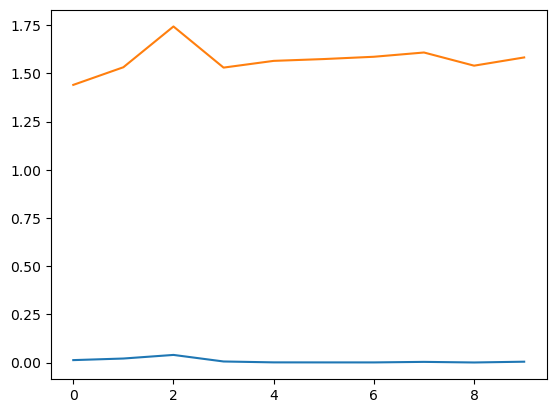

In [496]:
plt.plot(loss_df_torch['epoch'],loss_df_torch['train_loss'],label='Train Loss') 
plt.plot(loss_df_torch['epoch'],loss_df_torch['test_loss'],label='Test Loss')

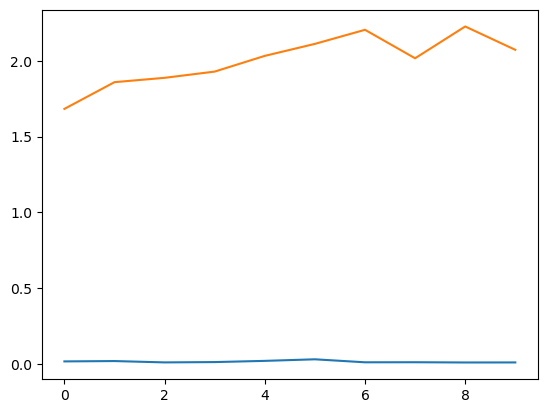

In [497]:
plt.plot(loss_df_my['epoch'],loss_df_my['train_loss'],label='Train Loss') 
plt.plot(loss_df_my['epoch'],loss_df_my['test_loss'],label='Test Loss')

## Efficient Multi-Head Attention

In [498]:
class MyEfficientMultiHeadAttention(torch.nn.Module):
    def __init__(self, embed_dim: int, n_heads: int, projection_bias=False):
        super().__init__()
        assert embed_dim % n_heads == 0, "embed_dim must be divisible by n_heads"
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.head_embed_dim = self.embed_dim // n_heads
        self.W_q = torch.nn.Linear(embed_dim, embed_dim, bias=projection_bias)
        self.W_k = torch.nn.Linear(embed_dim, embed_dim, bias=projection_bias)
        self.W_v = torch.nn.Linear(embed_dim, embed_dim, bias=projection_bias)
        self.projection = torch.nn.Linear(embed_dim, embed_dim, bias=projection_bias)

    def forward(self, query, key, value):
        # shape of query = (bs, seq_len, embed_dim)
        batch_size = query.size(0)

        # linear projection of query, key and value
        q = self.W_q(query)
        k = self.W_k(key)
        v = self.W_v(value)

        # reshape the projected query, key, value
        # to (bs, n_heads, seq_len, head_embed_dim)
        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        # do scaled dot product attention
        # attn.shape = (bs, n_heads, seq_len, head_embed_dim)
        # attn_weights.shape (bs, n_heads, seq_len, seq_len)
        attn, attn_weights = my_scaled_dot_product_attention(q, k, v)
        # swap the n_heads and seq_len so that we have
        # (bs, seq_len, n_heads, head_embed_dim)
        # call .contiguous() so that view function will work later
        attn = attn.transpose(1, 2).contiguous()
        # "combine" (n_heads, head_embed_dim) matrix as a single "embed_dim" vector
        attn = attn.view(batch_size, -1, self.embed_dim)

        output = self.projection(attn)
        return output, attn_weights.mean(dim=1)

    def split_heads(self, x):
        # x.shape = (bs, seq_len, embed_dim)
        batch_size = x.size(0)
        # first split the embed_dim into (n_heads, head_embed_dim)
        temp =  x.view(batch_size, -1, self.n_heads, self.head_embed_dim)
        # now we swap seq_len and n_heads dimension
         # output shape = (bs, n_heads, seq_len, head_embed_dim)
        return temp.transpose(1, 2)


In [499]:
# mha=MyEfficientMultiHeadAttention(6,3)
# print(mha.embed_dim,mha.n_heads,mha.W_q,mha.W_k,mha.W_v)
# mha.forward(torch.rand((5,10,6)),torch.rand((5,10,6)),torch.rand((5,10,6)))

In [500]:
my_efficient_mha = MyEfficientMultiHeadAttention(embed_dim=embed_dim, n_heads=n_heads, projection_bias=True)
my_efficient_classifier = TextClassifier(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, num_classes=num_classes, mha=my_efficient_mha)
my_efficient_losses = train(my_efficient_classifier, train_dl, test_dl, epochs=10)

Epoch 1/10, Training Loss: 1.6048, Validation Loss: 1.5919, Validation Accuracy: 0.2671. Epoch Duration: 1.8 seconds
Epoch 3/10, Training Loss: 1.4335, Validation Loss: 1.2545, Validation Accuracy: 0.4788. Epoch Duration: 1.7 seconds
Epoch 5/10, Training Loss: 0.8233, Validation Loss: 0.8390, Validation Accuracy: 0.6938. Epoch Duration: 1.8 seconds
Epoch 7/10, Training Loss: 0.5478, Validation Loss: 0.6364, Validation Accuracy: 0.7557. Epoch Duration: 2.0 seconds
Epoch 9/10, Training Loss: 0.4087, Validation Loss: 0.5081, Validation Accuracy: 0.8176. Epoch Duration: 1.8 seconds
Epoch 10/10, Training Loss: 0.3465, Validation Loss: 0.4672, Validation Accuracy: 0.8274. Epoch Duration: 1.7 seconds
Training finished. Took 18.3 seconds


## Masking Padded Tokens

In [555]:
import torch
embed_dim = 4
mha = torch.nn.MultiheadAttention(embed_dim=embed_dim, num_heads=1, batch_first=True)

# assume we have a batch of 2 sentences. 1st has 3 tokens and 2nd has 2 tokens
embeddings = torch.normal(mean=0, std=1, size=(2, 3, embed_dim))
# # create a padding mask with all zeros so that every token is valid by default
key_padding_mask = torch.zeros(size=(2, 3), dtype=torch.bool)
# # 3rd token of second sentence is a pad token
key_padding_mask[1, 2] = 1

_, torch_attn_mask = mha(embeddings, embeddings, embeddings, key_padding_mask=key_padding_mask)


# reshape mask to proper shape
key_padding_mask_expanded = key_padding_mask.unsqueeze(1) # (bs, 1, seq_len)
# expand 3 times in the 2nd dimension since we have 3 tokens
key_padding_mask_expanded = key_padding_mask_expanded.expand(-1, 3, -1)
# print(key_padding_mask_expanded)


scores = embeddings @ embeddings.transpose(1, 2) ## Q*K.T
# create a float_mask as I describe previously
float_mask = torch.zeros_like(key_padding_mask_expanded, dtype=torch.float32).masked_fill(key_padding_mask_expanded, -torch.inf)
# add the float mask to the scores and apply softmax function
print(torch.softmax(scores + float_mask, dim=-1).round(decimals=2))

tensor([[[0.7100, 0.0100, 0.2900],
         [0.0000, 0.9900, 0.0000],
         [0.4300, 0.0200, 0.5600]],

        [[1.0000, 0.0000, 0.0000],
         [0.3700, 0.6300, 0.0000],
         [0.1100, 0.8900, 0.0000]]])


## Causal Masked Self-Attention

In [542]:
# we have 2 sentences and 3 tokens
causal_mask = torch.ones((2, 3, 3), dtype=torch.bool)
causal_mask = torch.triu(causal_mask, diagonal=1)
print(causal_mask,"\n")
print(mha(embeddings, embeddings, embeddings, attn_mask=causal_mask)[1])
print("\n\n\n\n")

### OR

causal_mask = torch.nn.Transformer.generate_square_subsequent_mask(sz=3) # we have 3 tokens, so size=3
print(causal_mask,"\n")
print(mha(embeddings, embeddings, embeddings, attn_mask=causal_mask)[1])

tensor([[[False,  True,  True],
         [False, False,  True],
         [False, False, False]],

        [[False,  True,  True],
         [False, False,  True],
         [False, False, False]]]) 

tensor([[[1.0000, 0.0000, 0.0000],
         [0.3610, 0.6390, 0.0000],
         [0.3982, 0.2478, 0.3540]],

        [[1.0000, 0.0000, 0.0000],
         [0.5456, 0.4544, 0.0000],
         [0.1729, 0.3208, 0.5064]]], grad_fn=<MeanBackward1>)





tensor([[0., -inf, -inf],
        [0., 0., -inf],
        [0., 0., 0.]]) 

tensor([[[1.0000, 0.0000, 0.0000],
         [0.3610, 0.6390, 0.0000],
         [0.3982, 0.2478, 0.3540]],

        [[1.0000, 0.0000, 0.0000],
         [0.5456, 0.4544, 0.0000],
         [0.1729, 0.3208, 0.5064]]], grad_fn=<MeanBackward1>)


In [ ]:
## Accelerated Learning - Gamma Waves for Focus / Concentration / Memory - Binaural Beats - Focus Music


# 9845246462

In [558]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load data or create batches
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data in batches
batch_size = 64
n_batches = (len(X_train) + batch_size - 1) // batch_size

for i in range(n_batches):
    start = i * batch_size
    end = min((i + 1) * batch_size, len(X_train))
    scaler.partial_fit(X_train[start:end])

# Transform training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = SVC()
model.fit(X_train_scaled, y_train)

# Predict on test data in batches
y_pred = []
n_batches_test = (len(X_test_scaled) + batch_size - 1) // batch_size

for i in range(n_batches_test):
    start = i * batch_size
    end = min((i + 1) * batch_size, len(X_test_scaled))
    y_pred.extend(model.predict(X_test_scaled[start:end]))

1285.54